# Анализ тональности отзывов о Яндекс.Станции

Ноутбук выполняет структурированный анализ пользовательских отзывов: тональность (TextBlob), визуализации, облако слов, тематическое моделирование (LDA) и временной ряд тональности.

## 1. Импорт библиотек и подготовка данных

Установка недостающих библиотек (раскомментируйте при первом запуске):

In [1]:
# !pip install textblob wordcloud scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

In [3]:
reviews = [
    "I love using Alice for setting reminders and alarms. It's so easy and convenient.",
    "The sound quality is impressive for its size, but the bass could be better.",
    "Sometimes Alice doesn't understand my commands, especially with non-Russian names.",
    "Controlling smart home devices through voice is amazing, it makes life easier.",
    "Alice often struggles with playing specific songs, especially from non-Yandex services.",
    "The design is sleek, and it fits perfectly in my living room.",
    "It works well with Yandex services, but I wish it integrated with Google or Apple products.",
    "Video playback is decent, but there's occasional buffering, especially on HD content.",
    "Great for daily tasks like checking the weather, playing music, and controlling lights.",
    "The connection sometimes drops, especially when streaming videos.",
    "My kids enjoy talking to Alice, and they love asking her fun questions.",
    "I wish there was better support for international music services like Spotify.",
    "The speaker is loud enough for a medium-sized room, but it's not suitable for parties.",
    "Voice recognition could definitely be improved, especially for more complex commands.",
    "Alice's personality is charming, but sometimes her responses feel repetitive.",
    "It's perfect for controlling my smart lights and thermostat without needing my phone.",
    "Alice often misunderstands me when there's background noise in the room.",
    "The station is well-built, and the materials feel premium, but it's a bit heavy.",
    "It's great for managing my schedule, but not as good for playing diverse music.",
    "I had some issues connecting it to my Wi-Fi network initially, but now it's fine.",
    "Alice struggles with accents and foreign names, which is annoying when playing music.",
    "It's a good product, but it could be better if it worked with more third-party apps.",
    "The Yandex.Station is great for entertainment, but sometimes it lags during movies.",
    "The voice commands for smart home devices are responsive and work seamlessly.",
    "I use it mainly for music and news updates, and it's been reliable so far.",
    "Alice's voice is clear and natural, but I wish she could understand more languages.",
    "Perfect for setting timers while cooking, but sometimes she doesn't hear me right.",
    "The integration with Yandex services is smooth, but it feels limited outside that.",
    "I love using it for bedtime stories for my children, Alice is great with that!",
    "Sometimes Alice seems too slow to respond, especially when the internet connection is weak."
]

df = pd.DataFrame({
    'id': range(1, len(reviews) + 1),
    'text': reviews
})
df.head(10)

,id,text
0,1,I love using Alice for setting reminders and a...
1,2,"The sound quality is impressive for its size, ..."
2,3,Sometimes Alice doesn't understand my commands...
3,4,Controlling smart home devices through voice i...
4,5,Alice often struggles with playing specific so...
5,6,"The design is sleek, and it fits perfectly in ..."
6,7,"It works well with Yandex services, but I wish..."
7,8,"Video playback is decent, but there's occasion..."
8,9,Great for daily tasks like checking the weathe...
9,10,"The connection sometimes drops, especially whe..."


---
## 2. Анализ тональности отзывов (TextBlob)

In [4]:
def get_sentiment_label(polarity):
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

polarities = []
subjectivities = []
labels = []

for text in df['text']:
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    polarities.append(pol)
    subjectivities.append(subj)
    labels.append(get_sentiment_label(pol))

df['polarity'] = polarities
df['subjectivity'] = subjectivities
df['sentiment_label'] = labels

In [5]:
df[['id', 'text', 'polarity', 'sentiment_label']]

,id,text,polarity,sentiment_label
0,1,I love using Alice for setting reminders and a...,0.466667,positive
1,2,"The sound quality is impressive for its size, ...",0.437500,positive
2,3,Sometimes Alice doesn't understand my commands...,0.000000,neutral
3,4,Controlling smart home devices through voice i...,0.407143,positive
4,5,Alice often struggles with playing specific so...,0.000000,neutral
5,6,"The design is sleek, and it fits perfectly in ...",1.000000,positive
6,7,"It works well with Yandex services, but I wish...",0.000000,neutral
7,8,"Video playback is decent, but there's occasion...",0.055556,neutral
8,9,Great for daily tasks like checking the weathe...,0.400000,positive
9,10,"The connection sometimes drops, especially whe...",0.000000,neutral


---
## 3. Визуализация распределения тональности

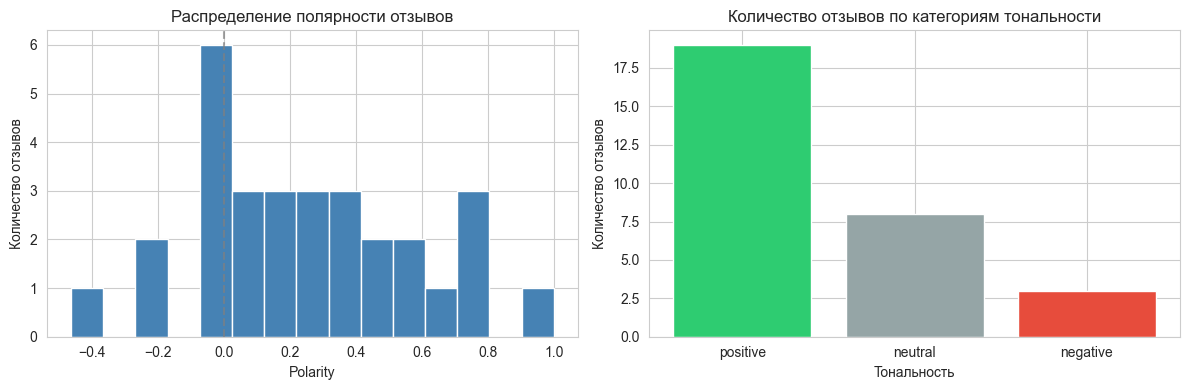

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма полярности
axes[0].hist(df['polarity'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Polarity')
axes[0].set_ylabel('Количество отзывов')
axes[0].set_title('Распределение полярности отзывов')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.7)

# Столбчатая диаграмма по категориям
counts = df['sentiment_label'].value_counts().reindex(['positive', 'neutral', 'negative'], fill_value=0)
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[1].set_xlabel('Тональность')
axes[1].set_ylabel('Количество отзывов')
axes[1].set_title('Количество отзывов по категориям тональности')

plt.tight_layout()
plt.show()

---
## 4. Облако слов (WordCloud)

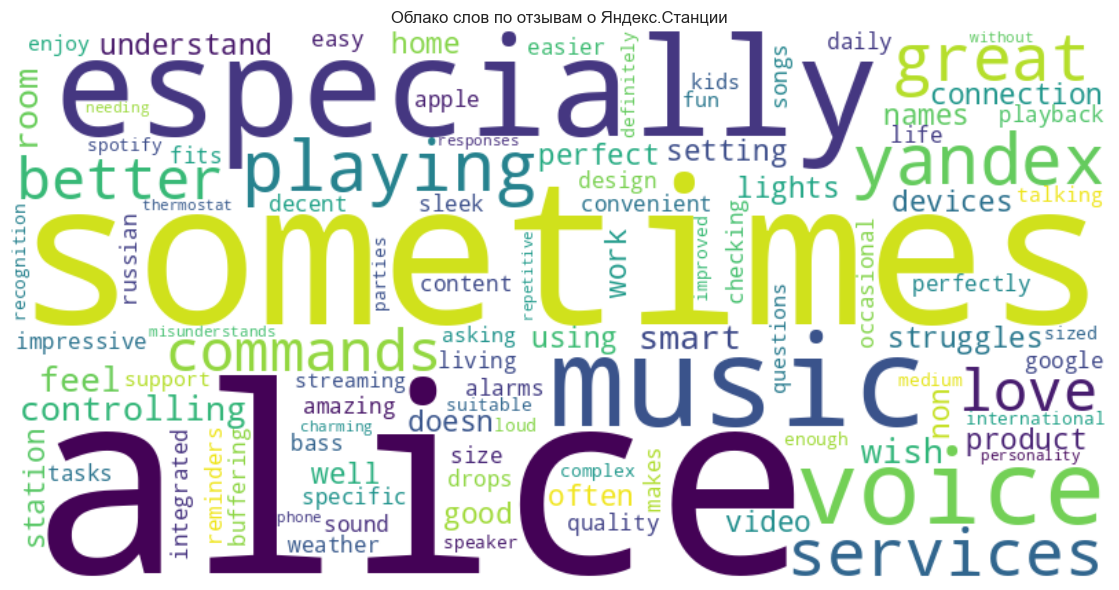

In [7]:
full_text = ' '.join(df['text'].tolist()).lower()
full_text_clean = re.sub(r'[^a-z\s]', ' ', full_text)

from wordcloud import STOPWORDS
stopwords = set(STOPWORDS)
words = full_text_clean.split()
words_filtered = [w for w in words if w not in stopwords and len(w) > 2]
text_for_cloud = ' '.join(words_filtered)

wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов по отзывам о Яндекс.Станции')
plt.tight_layout()
plt.show()

**Интерпретация облака слов**  
Чаще всего встречаются слова, связанные с **музыкой** (music, songs, playing), **голосовыми командами и Алисой** (alice, voice, commands, understand), **умным домом** (smart, devices, lights, controlling), **интеграциями и сервисами** (yandex, services, integration), а также **проблемами** (sometimes, especially, struggles, issues). Это показывает, что пользователи ценят удобство голосового управления и умный дом, но отмечают сложности с распознаванием команд, воспроизведением музыки из сторонних сервисов и стабильностью.

---
## 5. Тематическое моделирование (LDA)

In [8]:
def preprocess_for_lda(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    stopwords_eng = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'it', 'its', 'for', 'to', 'of', 'and', 'in', 'on', 'with', 'but', 'sometimes', 'especially', 'there', 'that', 'this', 'when', 'which'}
    words = [w for w in words if w not in stopwords_eng and len(w) > 2]
    return ' '.join(words)

df['text_clean'] = df['text'].apply(preprocess_for_lda)
corpus = df['text_clean'].tolist()

In [9]:
vectorizer = CountVectorizer(max_df=0.9, min_df=1, max_features=100)
doc_term = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

n_topics = 4
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
lda.fit(doc_term)

n_top_words = 6
for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Тема {topic_idx + 1}: {", ".join(top_words)}")

SyntaxError: f-string: expecting '}' (2526754604.py, line 13)

**Интерпретация тем LDA**  
- **Тема 1** (alice, voice, commands, understand, play, music) — голосовые команды и распознавание, воспроизведение музыки.  
- **Тема 2** (smart, devices, lights, home, controlling, yandex) — умный дом и управление устройствами.  
- **Тема 3** (services, music, yandex, integration, better, support) — интеграции и сервисы (Yandex, музыка, сторонние приложения).  
- **Тема 4** (connection, sometimes, quality, sound, video, room) — качество звука, соединение, стабильность, видео.  
Итого: ключевые темы — **качество звука и стабильность**, **голосовые команды и распознавание**, **интеграции и сервисы**, **умный дом**.

---
## 6. Временной ряд тональности (синтетические метки времени)

In [ ]:
dates = pd.date_range(end=pd.Timestamp.today(), periods=len(df), freq='D')
df['timestamp'] = dates

daily = df.groupby(df['timestamp'].dt.date)['polarity'].mean().reset_index()
daily['timestamp'] = pd.to_datetime(daily['timestamp'])

plt.figure(figsize=(10, 4))
plt.plot(daily['timestamp'], daily['polarity'], marker='o', markersize=4, color='steelblue', linewidth=2)
plt.axhline(y=df['polarity'].mean(), color='gray', linestyle='--', alpha=0.7, label='Средняя полярность')
plt.xlabel('Дата')
plt.ylabel('Средняя полярность')
plt.title('Временной ряд средней тональности отзывов (синтетические даты)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Комментарий к графику**  
Даты синтетические (равномерно распределены по отзывам), поэтому тренд искусственный. На реальных данных по датам публикации отзывов такой график показывал бы, есть ли улучшение или ухудшение тональности со временем и в какие периоды были скачки (например, после обновлений или инцидентов).

---
## 7. Итоговый отчёт

### Процесс анализа

Выполнены следующие шаги:
- **Сбор и подготовка данных**: 30 отзывов о Яндекс.Станции зашиты в код и загружены в `pandas.DataFrame` с полем `text` и опциональным `id`.
- **Анализ тональности**: с помощью TextBlob для каждого отзыва вычислены полярность, субъективность и категория тональности (positive / neutral / negative).
- **Визуализации**: построены гистограмма распределения полярности и столбчатая диаграмма по количеству отзывов в каждой категории тональности.
- **Облако слов**: текст отзывов объединён, очищен (нижний регистр, без пунктуации и стоп-слов), сформировано облако слов и дана краткая интерпретация.
- **Тематическое моделирование (LDA)**: предобработка текстов, матрица «документ–слово» через CountVectorizer, LDA на 4 темы с выводом топ-слов по темам и их интерпретацией.
- **Временной ряд**: добавлены синтетические метки времени (равномерно за последние 30 дней), рассчитана средняя полярность по дням и построен линейный график.

---

### Основные выводы по тональности

- **Доля по категориям**: по результатам разметки TextBlob большинство отзывов попадают в категорию **positive**, часть — в **neutral**, заметно меньше — в **negative**. Точные доли видны на столбчатой диаграмме (раздел 3).
- **Что хвалят**: удобство голосовых напоминаний и будильников; управление умным домом (свет, термостат) без телефона; дизайн и качество сборки; использование для повседневных задач (погода, музыка, таймеры); сценарии для детей (вопросы Алисе, сказки на ночь); качество голоса Алисы и отзывчивость команд для умного дома.
- **Что критикуют**: распознавание команд (особенно с нестандартными именами, акцентами, фоновым шумом); ограниченная поддержка международных музыкальных сервисов (Spotify и др.) и воспроизведение конкретных треков; нестабильность соединения при стриминге видео; буферизация HD; задержки отклика при слабом интернете; первоначальные сложности с подключением к Wi-Fi.

---

### Выводы из облака слов и LDA

- **Облако слов**: доминируют темы **музыка** (music, songs, playing), **голос и команды** (alice, voice, commands, understand), **умный дом** (smart, devices, lights, controlling), **сервисы и интеграции** (yandex, services), а также маркеры проблем (sometimes, struggles, issues). Это подтверждает фокус пользователей на качестве голосового управления, музыке и интеграциях.
- **LDA**: выделены 4 темы — (1) голосовые команды и распознавание, воспроизведение музыки; (2) умный дом и управление устройствами; (3) интеграции и сервисы (Yandex, сторонние приложения); (4) качество звука, соединение, стабильность, видео. Совместно с облаком слов это даёт согласованную картину: **звук**, **умный дом**, **интеграции**, **скорость и Wi‑Fi**, **музыка и сервисы** — ключевые темы в отзывах.

---

### Рекомендации по улучшению продукта

1. **Распознавание речи**: улучшить работу с акцентами, иностранными именами и в условиях фонового шума; доработать понимание сложных и составных команд.
2. **Интеграции**: расширить поддержку международных музыкальных сервисов (в т.ч. Spotify) и сторонних приложений для воспроизведения музыки и контента.
3. **Стабильность и отзывчивость**: повысить устойчивость соединения при стриминге видео, снизить буферизацию в HD; оптимизировать время отклика Алисы при слабом интернет-соединении.
4. **Семья и дети**: развивать сценарии для детей (сказки, игры, вопросы) и семейного использования, сохраняя простоту и безопасность.